<a href="https://colab.research.google.com/github/amish4462-oss/Flipkart-Product-Classifier-CNN/blob/main/Flipkart_Product_Classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np

# 1. GPU Verification
print("TensorFlow Version:", tf.__version__)
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print("🚀 T4 GPU Active hai! Training fast hogi.")
else:
    print("⚠️ CPU mode par hai. Top menu -> Runtime -> Change runtime type -> T4 GPU select karo.")

# 2. Product Dataset Load (E-commerce Benchmark)
print("\nProduct Dataset Load Ho Raha Hai...")
fashion_mnist = tf.keras.datasets.fashion_mnist
(train_images, train_labels), (test_images, test_labels) = fashion_mnist.load_data()

# Category Labels Map
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

print(f"Total Training Images: {train_images.shape[0]}")
print(f"Total Testing Images: {test_images.shape[0]}")
print("Setup Complete & Ready! 🎉")

TensorFlow Version: 2.20.0
⚠️ CPU mode par hai. Top menu -> Runtime -> Change runtime type -> T4 GPU select karo.

Product Dataset Load Ho Raha Hai...
29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Total Training Images: 60000
Total Testing Images: 10000
Setup Complete & Ready! 🎉


In [2]:
# 1. Images Data Normalize Karo (0-255 pixels ko 0.0-1.0 range me lana)
train_images = train_images / 255.0
test_images = test_images / 255.0

# Images ko CNN ke according reshape karna (28x28x1 format)
train_images = train_images.reshape((-1, 28, 28, 1))
test_images = test_images.reshape((-1, 28, 28, 1))

# 2. CNN Model Architecture Create Karo
model = models.Sequential([
    # Convolutional Layers (Feature Extracting)
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Dense Classifier Layers
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3), # Overfitting rokhne ke liye
    layers.Dense(10, activation='softmax') # 10 Product Categories Output
])

# 3. Model Compile Karo
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

print("🧠 CNN Model Architecture Ready!")
print("🚀 Model Training Started on GPU (5 Epochs)...")

# 4. Model Training (Training Phase)
history = model.fit(train_images, train_labels, epochs=5,
                    validation_data=(test_images, test_labels))

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


🧠 CNN Model Architecture Ready!
🚀 Model Training Started on GPU (5 Epochs)...
Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 62s 32ms/step - accuracy: 0.8124 - loss: 0.5138 - val_accuracy: 0.8599 - val_loss: 0.3804
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 80s 31ms/step - accuracy: 0.8724 - loss: 0.3501 - val_accuracy: 0.8775 - val_loss: 0.3409
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 58s 31ms/step - accuracy: 0.8895 - loss: 0.3019 - val_accuracy: 0.8956 - val_loss: 0.2910
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 83s 32ms/step - accuracy: 0.9003 - loss: 0.2747 - val_accuracy: 0.8985 - val_loss: 0.2766
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 58s 31ms/step - accuracy: 0.9070 - loss: 0.2523 - val_accuracy: 0.9016 - val_loss: 0.2720


🔍 Analyzing Model Performance...
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step


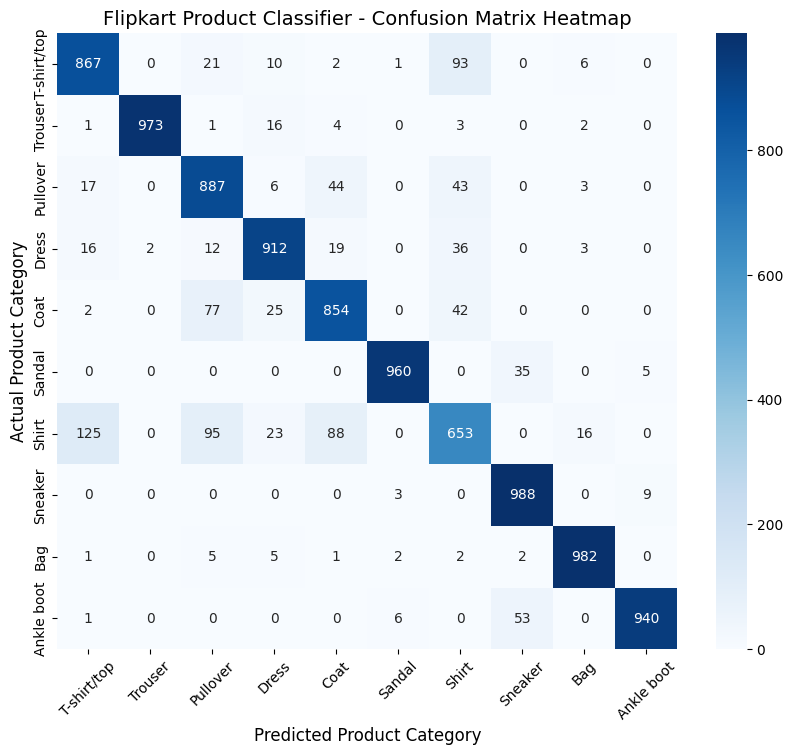


📊 Detailed Classification Report:

              precision    recall  f1-score   support

 T-shirt/top       0.84      0.87      0.85      1000
     Trouser       1.00      0.97      0.99      1000
    Pullover       0.81      0.89      0.85      1000
       Dress       0.91      0.91      0.91      1000
        Coat       0.84      0.85      0.85      1000
      Sandal       0.99      0.96      0.97      1000
       Shirt       0.75      0.65      0.70      1000
     Sneaker       0.92      0.99      0.95      1000
         Bag       0.97      0.98      0.98      1000
  Ankle boot       0.99      0.94      0.96      1000

    accuracy                           0.90     10000
   macro avg       0.90      0.90      0.90     10000
weighted avg       0.90      0.90      0.90     10000



In [3]:
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# 1. Predictions Generate Karo
print("🔍 Analyzing Model Performance...")
y_pred = model.predict(test_images)
y_pred_classes = np.argmax(y_pred, axis=1)

# 2. Confusion Matrix Calculate Karo
cm = confusion_matrix(test_labels, y_pred_classes)

# 3. Heatmap Plot Karo
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Flipkart Product Classifier - Confusion Matrix Heatmap', fontsize=14)
plt.xlabel('Predicted Product Category', fontsize=12)
plt.ylabel('Actual Product Category', fontsize=12)
plt.xticks(rotation=45)
plt.show()

# 4. Final Classification Report
print("\n📊 Detailed Classification Report:\n")
print(classification_report(test_labels, y_pred_classes, target_names=class_names))